In [1]:
papers = [
    # Machine Learning Papers
    {
        'title': 'Building Your First Neural Network with PyTorch',
        'abstract': '''Learn how to construct and train a neural network from scratch using PyTorch. This paper covers the fundamentals of defining layers, activation functions, and forward propagation. You'll build a multi-layer perceptron for classification tasks, understand backpropagation, and implement gradient descent optimization. By the end, you'll have a working model that achieves over 90% accuracy on the MNIST dataset.'''
    },
    {
        'title': 'Preventing Overfitting: Regularization Techniques Explained',
        'abstract': '''Overfitting is one of the most common challenges in machine learning. This guide explores practical regularization methods including L1 and L2 regularization, dropout layers, and early stopping. You'll learn how to detect overfitting by monitoring training and validation loss, implement regularization in both scikit-learn and TensorFlow, and tune regularization hyperparameters to improve model generalization on unseen data.'''
    },
    {
        'title': 'Hyperparameter Tuning with Grid Search and Random Search',
        'abstract': '''Selecting optimal hyperparameters can dramatically improve model performance. This paper demonstrates systematic approaches to hyperparameter optimization using grid search and random search. You'll learn how to define hyperparameter spaces, implement cross-validation during tuning, and use scikit-learn's GridSearchCV and RandomizedSearchCV. We'll compare both methods and discuss when to use each approach for efficient model optimization.'''
    },
    {
        'title': 'Transfer Learning: Using Pre-trained Models for Image Classification',
        'abstract': '''Transfer learning lets you leverage pre-trained models to solve new problems with limited data. This paper shows how to use pre-trained convolutional neural networks like ResNet and VGG for custom image classification tasks. You'll learn how to freeze layers, fine-tune network weights, and adapt pre-trained models to your specific domain. We'll build a classifier that achieves high accuracy with just a few hundred training images.'''
    },

    # Data Engineering/ETL Papers
    {
        'title': 'Handling Missing Data: Strategies and Best Practices',
        'abstract': '''Missing data can derail your analysis if not handled properly. This comprehensive guide covers detection methods for missing values, statistical techniques for understanding missingness patterns, and practical imputation strategies. You'll learn when to use mean imputation, forward fill, and more sophisticated approaches like KNN imputation. We'll work through real datasets with missing values and implement robust solutions using pandas.'''
    },
    {
        'title': 'Data Validation Techniques for ETL Pipelines',
        'abstract': '''Building reliable data pipelines requires thorough validation at every stage. This paper teaches you how to implement data quality checks, define validation rules, and catch errors before they propagate downstream. You'll learn schema validation, outlier detection, and referential integrity checks. We'll build a validation framework using Great Expectations and integrate it into an automated ETL workflow for production data systems.'''
    },
    {
        'title': 'Cleaning Messy CSV Files: A Practical Guide',
        'abstract': '''Real-world CSV files are rarely clean and analysis-ready. This hands-on paper walks through common data quality issues: inconsistent formatting, duplicate records, invalid entries, and encoding problems. You'll master pandas techniques for standardizing column names, removing duplicates, handling date parsing errors, and dealing with mixed data types. We'll transform a messy CSV with multiple quality issues into a clean dataset ready for analysis.'''
    },
    {
        'title': 'Building Scalable ETL Workflows with Apache Airflow',
        'abstract': '''Apache Airflow helps you build, schedule, and monitor complex data pipelines. This paper introduces Airflow's core concepts including DAGs, operators, and task dependencies. You'll learn how to define pipeline workflows, implement retry logic and error handling, and schedule jobs for automated execution. We'll build a complete ETL pipeline that extracts data from APIs, transforms it, and loads it into a data warehouse on a daily schedule.'''
    },

    # Data Visualization Papers
    {
        'title': 'Creating Interactive Dashboards with Plotly Dash',
        'abstract': '''Interactive dashboards make data exploration intuitive and engaging. This paper teaches you how to build web-based dashboards using Plotly Dash. You'll learn to create interactive charts with dropdowns, sliders, and date pickers, implement callbacks for dynamic updates, and design responsive layouts. We'll build a complete dashboard for exploring sales data with filters, multiple chart types, and real-time updates.'''
    },
    {
        'title': 'Matplotlib Best Practices: Making Publication-Quality Plots',
        'abstract': '''Creating clear, professional visualizations requires attention to design principles. This guide covers matplotlib best practices for publication-quality plots. You'll learn about color palette selection, font sizing and typography, axis formatting, and legend placement. We'll explore techniques for reducing chart clutter, choosing appropriate chart types, and creating consistent styling across multiple plots for research papers and presentations.'''
    },
    {
        'title': 'Data Storytelling: Designing Effective Visualizations',
        'abstract': '''Good visualizations tell a story and guide viewers to insights. This paper focuses on the principles of visual storytelling and effective chart design. You'll learn how to choose the right visualization for your data, apply pre-attentive attributes to highlight key information, and structure narratives through sequential visualizations. We'll analyze both effective and ineffective visualizations, discussing what makes certain design choices successful.'''
    },
    {
        'title': 'Building Real-Time Visualization Streams with Bokeh',
        'abstract': '''Visualizing streaming data requires specialized techniques and tools. This paper demonstrates how to create real-time updating visualizations using Bokeh. You'll learn to implement streaming data sources, update plots dynamically as new data arrives, and optimize performance for continuous updates. We'll build a live monitoring dashboard that displays streaming sensor data with smoothly updating line charts and real-time statistics.'''
    }
]

Now let's transform these paper abstracts into embeddings. We'll use a pre-trained model from the `sentence-transformers` library called `all-MiniLM-L6-v2`. We're using this model because it's fast and efficient for learning purposes


The model will convert each abstract into an n-dimensional vector, where the value of n depends on the specific model architecture. Different embedding models produce vectors of different sizes. Some models create compact 128-dimensional embeddings, while others produce larger 768 or even 1024-dimensional vectors. Generally, larger embeddings can capture more nuanced semantic information, but they also require more computational resources and storage space.

Think of each dimension in the vector as capturing some aspect of the text's meaning. Maybe one dimension responds strongly to "machine learning" concepts, another to "data cleaning" terminology, and another to "visualization" language. The model learned these representations automatically during training.

In [2]:
from sentence_transformers import SentenceTransformer

# Load the pre-trained embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Extract just the abstracts for embedding
abstracts = [paper['abstract'] for paper in papers]

# Generate embeddings for all abstracts
embeddings = model.encode(abstracts)

# Let's examine what we've created
print(f"Shape of embeddings: {embeddings.shape}")
print(f"Each abstract is represented by a vector of {embeddings.shape[1]} numbers")
print("\nFirst few values of the first embedding:")
print(embeddings[0][:10])

/home/fbernardi/Documents/personal/embeddings_viz/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape of embeddings: (12, 384)
Each abstract is represented by a vector of 384 numbers

First few values of the first embedding:
[-0.06071811 -0.1306487   0.00328695 -0.04209429 -0.03220839  0.02034251
  0.00421556 -0.01300784 -0.1026611  -0.04565619]


Perfect! We now have 12 embeddings, one for each paper abstract. Each embedding is a 384-dimensional vector, represented as a NumPy array of floating-point numbers.

These numbers might look random at first, but they encode meaningful information about the semantic content of each abstract. When we want to find similar documents, we measure the cosine similarity between their embedding vectors. Cosine similarity looks at the angle between vectors. Vectors pointing in similar directions (representing similar meanings) have high cosine similarity, even if their magnitudes differ.




We now have 12 vectors, each with 384 dimensions. But here's the issue: humans can't visualize 384-dimensional space. We struggle to imagine even four dimensions! To understand what our embeddings have learned, we need to reduce them to two dimensions so that we can plot them on a graph.

This is where dimensionality reduction is a good skill to have. We'll use Principal Component Analysis (PCA), a technique we can use to find the two most important dimensions (the ones that capture the most variation in our data). It's like taking a 3D object and finding the best angle to photograph it in 2D while preserving as much information as possible.

While we're definitely going to lose some detail during this compression, our original 384-dimensional embeddings capture rich, nuanced information about semantic meaning. When we squeeze them down to 2D, some subtleties are bound to get lost. But the major patterns (which papers belong to which topic) will still be clearly visible.

In [3]:
from sklearn.decomposition import PCA

# Reduce embeddings from 384 dimensions to 2 dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print(f"Original embedding dimensions: {embeddings.shape[1]}")
print(f"Reduced embedding dimensions: {embeddings_2d.shape[1]}")
print(f"\nVariance explained by these 2 dimensions: {pca.explained_variance_ratio_.sum():.2%}")

Original embedding dimensions: 384
Reduced embedding dimensions: 2

Variance explained by these 2 dimensions: 41.20%


The variance explained tells us how much of the variation in the original data is preserved in these 2 dimensions. Think of it this way: if all our papers were identical, they'd have zero variance. The more different they are, the more variance. We've kept about 41% of that variation, which is plenty to see the major patterns. The clustering itself depends on whether papers use similar vocabulary, not on how much variance we've retained. So even though 41% might seem relatively low, the major patterns separating different topics will still be very clear in our embedding visualization.

In [4]:
# Print papers grouped by topic
print("=" * 80)
print("PAPER REFERENCE GUIDE")
print("=" * 80)

topics = [
    ("Machine Learning", list(range(0, 4))),
    ("Data Engineering/ETL", list(range(4, 8))),
    ("Data Visualization", list(range(8, 12)))
]

for topic_name, indices in topics:
    print(f"\n{topic_name}:")
    print("-" * 80)
    for idx in indices:
        print(f"  Paper {idx+1}: {papers[idx]['title']}")

PAPER REFERENCE GUIDE

Machine Learning:
--------------------------------------------------------------------------------
  Paper 1: Building Your First Neural Network with PyTorch
  Paper 2: Preventing Overfitting: Regularization Techniques Explained
  Paper 3: Hyperparameter Tuning with Grid Search and Random Search
  Paper 4: Transfer Learning: Using Pre-trained Models for Image Classification

Data Engineering/ETL:
--------------------------------------------------------------------------------
  Paper 5: Handling Missing Data: Strategies and Best Practices
  Paper 6: Data Validation Techniques for ETL Pipelines
  Paper 7: Cleaning Messy CSV Files: A Practical Guide
  Paper 8: Building Scalable ETL Workflows with Apache Airflow

Data Visualization:
--------------------------------------------------------------------------------
  Paper 9: Creating Interactive Dashboards with Plotly Dash
  Paper 10: Matplotlib Best Practices: Making Publication-Quality Plots
  Paper 11: Data Storyte

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

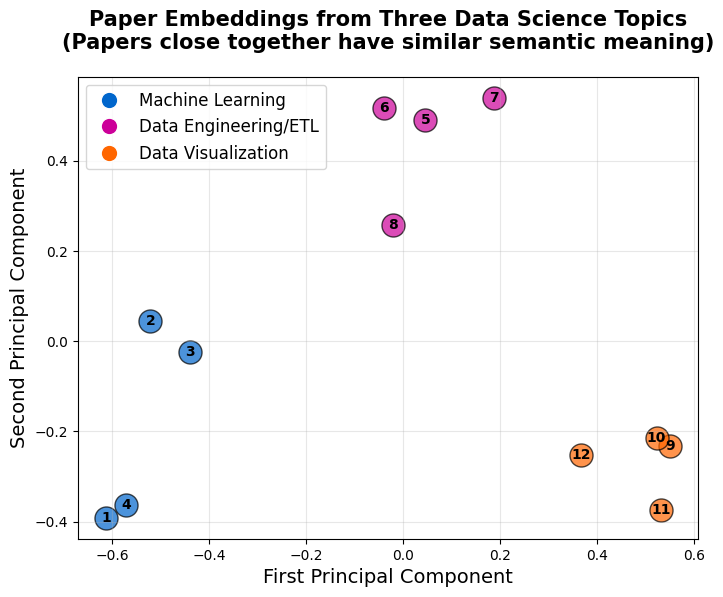

In [ ]:
import matplotlib.pyplot as plt

# Create the visualization
plt.figure(figsize=(8, 6))

# Define colors for different topics
colors = ['#0066CC', '#CC0099', '#FF6600']
categories = ['Machine Learning', 'Data Engineering/ETL', 'Data Visualization']

# Create color mapping for each paper
color_map = []
for i in range(12):
    if i < 4:
        color_map.append(colors[0])  # Machine Learning
    elif i < 8:
        color_map.append(colors[1])  # Data Engineering
    else:
        color_map.append(colors[2])  # Data Visualization

# Plot each paper
for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y, c=color_map[i], s=275, alpha=0.7, edgecolors='black', linewidth=1)
    # Add paper numbers as labels
    plt.annotate(str(i+1), (x, y), fontsize=10, fontweight='bold',
                ha='center', va='center')

plt.xlabel('First Principal Component', fontsize=14)
plt.ylabel('Second Principal Component', fontsize=14)
plt.title('Paper Embeddings from Three Data Science Topics\n(Papers close together have similar semantic meaning)',
          fontsize=15, fontweight='bold', pad=20)

# Add a legend showing which colors represent which topics
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors[i], markersize=12,
                              label=categories[i]) for i in range(len(categories))]
plt.legend(handles=legend_elements, loc='best', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout

we deliberately chose papers from very distinct topics to make the clustering crystal clear. This is perfect for learning, but real-world datasets are messier. When you're working with papers that bridge multiple topics or have overlapping vocabulary, you'll see more gradual transitions between clusters rather than these sharp separations.

The [`all-MiniLM-L6-v2` embedding model](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)  was trained on millions of text pairs, learning which words tend to appear together. When it sees a tutorial full of words like "layers," "training," and "optimization," it produces an embedding vector that's mathematically similar to other texts with that same vocabulary pattern. The clustering emerges naturally from those learned associations.